# Spectrogram Segmentation

In this example, we use [PyTorch](https://pytorch.org/) and [Lightning](https://lightning.ai/docs/pytorch/stable/) to train a deep learning model to identify and differentiate between 5G NR and 4G LTE signals within wideband spectrograms.

## Outline

**[Background](#Background):** Delve into the problem background and learn more about the machine learning frameworks, tools, and datasets used in this example.

**[Set-up](#Set-Up):** Install the libraries necessary to run the code in this notebook.

**[Data Preprocessing](#Data-Preprocessing):** Load and analyze the Spectrum Sensing dataset.

**[Model Training](#Model-Training):** Configure and train a DeepLabV3 model with a MobileNetV3 backbone.

**[Model Validation](#Model-Validation):** Assess the performance of the model using a suite of common machine learning metrics.

**[Challenge Data](#Challenge-Data):** Challenge the model on combined frames containing both LTE and NR signal.

**[Conclusions & Next Steps](#Conclusions-&-Next-Steps):** Interpret the results, summarize key learnings, and identify steps for expanding upon this example.

## Background

5G NR (New Radio) and 4G LTE (Long-Term Evolution) are both cellular network technologies, but they represent 
different generations of mobile network standards. The ability to identify and distinguish between the two holds significant 
applications in [spectrum sensing](https://iopscience.iop.org/article/10.1088/1742-6596/2261/1/012016), and serves as a foundational example showcasing the near-term feasibility of 
[intelligent radio](https://www.qoherent.ai/intelligentradio/) technology.

A spectrogram, which depicts the frequency spectrum of a signal over time, is essentially just an image. Therefore, we can
apply state-of-the-art [semantic segmentation](https://www.ibm.com/topics/semantic-segmentation) techniques from 
the field of computer vision to the problem of spectrogram analysis. Our task is to assign one of the 
following labels to each pixel in the spectrogram: 'LTE', 'NR', or 'Noise'. ('Noise' refers to the absence of signal, representing 
a vacant or empty spectrum, also known as whitespace.)

The machine learning model utilized in this example is a DeepLabV3 model with a MobileNetV3 (large) backbone. The DeepLabV3 framework was originally introduced by Chen _et al._ in their 2017 paper titled '[Rethinking Atrous Convolution for Semantic Image Segmentation](https://arxiv.org/abs/1706.05587) and the MobileNetV3 backbone was developed by Howard _et al._ and is further discussed in their 2019 paper titled '[Searching for MobileNetV3](https://arxiv.org/abs/1905.02244)'. For an accessible introduction to the DeepLabV3 framework, please check out Isaac Berrios' article: [DeepLabv3: Building Blocks for Robust Segmentation Models](https://medium.com/@itberrios6/deeplabv3-c0c8c93d25a4).

The dataset used in this example is the Spectrum Sensing dataset, provided by MathWorks. This dataset contains 900 LTE frames, 900 NR frames, and 900 combined frames with both LTE and NR signal. In this example, we train exclusively on the individual LTE and NR examples, excluding the combined frames from the training process.

# Set-Up

In this section, we will install the dependencies required to run the code in this notebook. These dependencies include libraries and packages for tasks such as data manipulation, visualization, and machine learning.

In [1]:
%matplotlib inline

In [2]:
import os
import statistics
from typing import Any, Optional

import h5py
import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.colors import ListedColormap
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay
from tabulate import tabulate
from torch import Tensor, nn
from torch.utils.data import DataLoader
from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassConfusionMatrix,
    MulticlassF1Score,
    MulticlassJaccardIndex,
    MulticlassPrecision,
    MulticlassRecall,
)
from torchvision.datasets import VisionDataset
from torchvision.models.segmentation import (  # noqa: F401
    deeplabv3_mobilenet_v3_large,
    deeplabv3_resnet50,
    deeplabv3_resnet101,
)
from torchvision.transforms.v2 import (
    Compose,
    Normalize,
    PILToTensor,
    ToDtype,
    ToPILImage,
)

In [3]:
title_font_size, label_font_size = 14, 12

# Data Preprocessing

In semantic segmentation, the input data typically consists of images (in this case, spectrograms), while the output data consists of pixel-wise labels (masks) where each pixel is assigned a category label (in this case, either 'LTE', 'NR', or 'Noise'). 

We will use [supervised learning](https://www.ibm.com/topics/supervised-learning) techniques to train our model. Therefore, we need both spectrograms and the corresponding target masks for training. 

The dataset used in this example is the MathWorks' Spectrum Sensing dataset. This dataset has been converted into the file format used by [Radio Intelligence Apps](https://qoherent.ai/radiointelligenceapps-project/), which contains both the spectrograms and masks within a single high-performance [HDF5](https://www.hdfgroup.org/solutions/hdf5/) file. The file structure is as follows:

The only metadata relevant to this example is `signal_type`, which can be one of the following:
- `LTE`: This frame contains only LTE signal.
- `NR`: This frame contains only NR signal.
- `LTE_NR`: This frame contains both LTE and NR signal.

Because spectrogram segmentation is a computer vision task, let's extend the [VisionDataset](https://pytorch.org/vision/main/generated/torchvision.datasets.VisionDataset.html) class.

In [4]:
class SpectrumSensing(VisionDataset):

    def __init__(
        self,
        source: str,
        transform: Optional[callable] = None,
        target_transform: Optional[callable] = None,
        combined: Optional[bool] = True,
    ):
        """Initialize a SpectrumSensing object from the dataset source file."""
        super().__init__()

        self.source = source
        self.transform, self.target_transform = transform, target_transform

        # Build an index map, mapping the indices of valid data entries to their corresponding indices in the
        # original dataset. This mapping enables the efficient retrieval of a subset of frames in the case
        # where combined == False.
        with h5py.File(self.source, "r") as f:
            metadata = f["metadata/metadata"]

            if combined:
                # Use all frames.
                valid_indices = range(0, len(metadata))

            else:
                # Use frames where the signal type is either 'LTE' or 'NR', but not 'LTE_NR'.
                df = pd.DataFrame(metadata[:])
                signal_types = df["signal_type"]
                valid_indices = [index for index, value in enumerate(signal_types.isin([b"LTE", b"NR"])) if value]

        self.index_map = {idx: valid_indices[idx] for idx in range(len(valid_indices))}

    def __len__(self) -> int:
        return len(self.index_map)

    def __getitem__(self, idx: int) -> tuple[Image, Image]:
        """Return the image-mask pair at idx."""
        if idx >= len(self):
            raise IndexError

        with h5py.File(self.source, "r") as f:
            images, masks = f["data"], f["masks"]
            image_arr, mask_arr = images[self.index_map[idx]], masks[self.index_map[idx]]
            image, mask = Image.fromarray(image_arr), Image.fromarray(mask_arr)

        if self.transform is not None:
            image = self.transform(image)

        if self.target_transform is not None:
            mask = self.target_transform(mask)

        return image, mask

Notice the `SpectrumSensing` class accepts two optional functions/transforms: `transform`, which is applied to the spectrogram, 
and `target_transform`, which is applied to the mask. Additionally, the class includes an optional parameter `combined`. When `combined == False`, only individual frames with either LTE or NR are included in the dataset. When `combined == True`, all frames are included, including combined frames containing both LTE and NR signals. 

Both the spectrograms and masks are 256 x 256 pixel images. However, the spectrograms are three channeled, while the masks are single-channeled. This is because the spectrograms are full RGB images, whereas the masks are ternary-valued images, where each pixel takes one of three discrete values:
- `0`: Representing noise.
- `1`: Representing NR signal.
- `2`: Representing LTE signal.

To prepare our spectrograms for training, we will convert them from PIL Images to Tensor objects. The images have to be loaded into the range `[0, 1]` and then normalized using a mean of `[0.485, 0.456, 0.406]` and a standard deviation of `[0.229, 0.224, 0.225]`, as required by our model. To prepare our masks for training, we will convert them to Tensor objects and remove the extraneous channel dimension.

In [5]:
project_root = os.getcwd()
source = os.path.join(project_root, "spectrum_sensing_dataset.hdf5")

mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]


class Squeeze(torch.nn.Module):
    def forward(self, target: Tensor):
        return torch.squeeze(target)


transform = Compose(
    [
        PILToTensor(),
        ToDtype(torch.float, scale=True),
        Normalize(mean=mean, std=std),
    ]
)

target_transform = Compose([PILToTensor(), Squeeze(), ToDtype(torch.long)])

Now, let's initialize the dataset, and take a closer look at a random training example and its corresponding mask. Due to our transforms, we expect that the image and mask will be returned as Tensor objects.

In [6]:
dataset = SpectrumSensing(source=source, transform=transform, target_transform=target_transform, combined=False)

In [7]:
random_index = np.random.randint(len(dataset))
training_example, corresponding_mask = dataset[random_index]

print(f"The full dataset has {len(dataset)} examples. Loading example at index {random_index}.")
print(f"Spectrogram: {type(training_example)}, {training_example.dtype}, {training_example.size()}")
print(f"Mask: {type(corresponding_mask)}, {corresponding_mask.dtype}, {corresponding_mask.size()}")

The full dataset has 1800 examples. Loading example at index 346.
Spectrogram: <class 'torch.Tensor'>, torch.float32, torch.Size([3, 256, 256])
Mask: <class 'torch.Tensor'>, torch.int64, torch.Size([256, 256])


The dataset should contain 1,800 samples: 900 NR frames and 900 LTE frames. 

To gain further insight, let's write some transforms to undo the previous normalization and prepare this image-mask pair for viewing. And, let's build a custom colormap for the masks, with noise as cyan, NR signal as blue, and LTE signal as purple.

In [8]:
inv_transform = Compose(
    [
        Normalize(mean=[0.0, 0.0, 0.0], std=[1 / x for x in std]),
        Normalize(mean=[-x for x in mean], std=[1.0, 1.0, 1.0]),
        ToPILImage(),
    ]
)

inv_target_transform = Compose([ToDtype(dtype=torch.uint8), ToPILImage()])

training_example = inv_transform(training_example)
corresponding_mask = inv_target_transform(corresponding_mask)

values, labels, colors = [0, 1, 2], ["Noise", "NR", "LTE"], ["cyan", "blue", "purple"]
mask_cmap = ListedColormap(colors)

print(f"Spectrogram: {training_example}")
print(f"Mask: {corresponding_mask}")

Spectrogram: <PIL.Image.Image image mode=RGB size=256x256 at 0x79DC989B3BC0>
Mask: <PIL.Image.Image image mode=L size=256x256 at 0x79DC989B3E00>


[Text(1, 0.33, 'Noise'), Text(1, 1.0, 'NR'), Text(1, 1.67, 'LTE')]

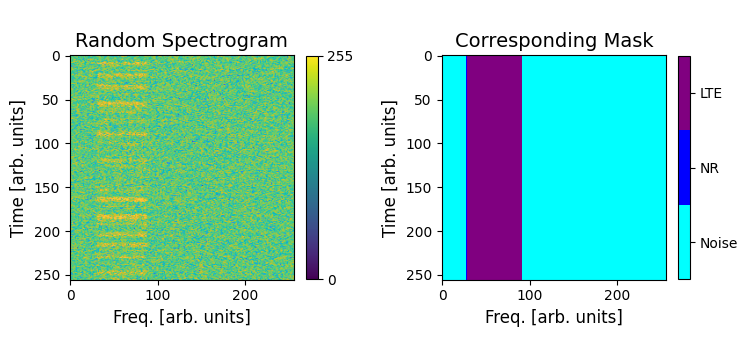

In [9]:
fig, (ax1, ax2) = plt.subplots(figsize=[8, 3.5], nrows=1, ncols=2)
plt.subplots_adjust(wspace=0.5)
ax1.set_title("\nRandom Spectrogram", fontsize=title_font_size)
ax2.set_title("Corresponding Mask", fontsize=title_font_size)
ax1.set_ylabel("Time [arb. units]", fontsize=label_font_size)
ax2.set_ylabel("Time [arb. units]", fontsize=label_font_size)
ax1.set_xlabel("Freq. [arb. units]", fontsize=label_font_size)
ax2.set_xlabel("Freq. [arb. units]", fontsize=label_font_size)

spect = ax1.imshow(training_example, vmin=0, vmax=255)
fig.colorbar(spect, ax=ax1, fraction=0.045, ticks=[0, 255])

mask = ax2.imshow(corresponding_mask, cmap=mask_cmap, vmin=0, vmax=2)
mask_cbar = fig.colorbar(mask, ax=ax2, cmap=mask_cmap, fraction=0.045, ticks=[0.33, 1, 1.67])
mask_cbar.ax.set_yticklabels(labels)

**Note:** You can view different examples from the dataset by rerunning the previous few code cells.

Let's analyze the relative frequencies of the different class labels. This step is critical for identifying imbalance in our dataset. Please note that the following code block might take a few seconds to run.

Text(0, 0.5, 'Counts (Normalized)')

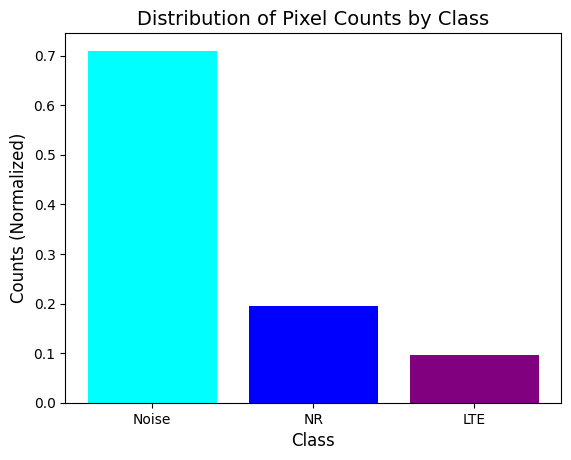

In [10]:
class_counts = {label: 0 for label in labels}

for _, mask in dataset:
    arr = np.asarray(mask)
    for i, label in enumerate(labels):
        class_counts[label] += np.sum(arr == values[i])

normalized_counts = np.array(list(class_counts.values())) / sum(list(class_counts.values()))

plt.bar(class_counts.keys(), normalized_counts, tick_label=labels, color=colors)
plt.title("Distribution of Pixel Counts by Class", fontsize=title_font_size)
plt.xlabel("Class", fontsize=label_font_size)
plt.ylabel("Counts (Normalized)", fontsize=label_font_size)

It looks like our dataset is mostly noise! A classification dataset like this—with skewed class proportions—is called imbalanced.

An imbalanced dataset can result in biased and poorly performing models. Models trained on imbalanced data tends to focus more on the majority classes and may not learn enough about the minority classes. To ensure the development of a fair, accurate, and robust model, we will need to address this class imbalance. 

But first, let's split the dataset into separate training and validation sets. The training dataset is the portion of the dataset that will be used to train the model, while the validation dataset will be held in reserve and used to evaluate the performance of the trained model. Let's start with a simple 80/20 split, where 80% of the dataset is used for training and 20% for validation.

In [11]:
train_split = 0.80
n_train_examples = int(len(dataset) * train_split)
n_val_examples = len(dataset) - n_train_examples

train_set, val_set = torch.utils.data.random_split(
    dataset=dataset, lengths=[n_train_examples, n_val_examples], generator=torch.Generator().manual_seed(42)
)

print(f"The training split contains {len(train_set)} examples.")
print(f"The validation split contains {len(val_set)} examples.")

The training split contains 1440 examples.
The validation split contains 360 examples.


In PyTorch, [DataLoaders](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html#preparing-your-data-for-training-with-dataloaders) efficiently load and batch data and offer numerous other features to streamline data preprocessing, management, and integration within the training loop. Let's create data loaders for both the training and validation datasets.

The `DataLoader` class allows us to pass a `batch_size` argument, which controls the number of samples used in each pass through the network. Using a small number of training examples each pass is called mini-batching, and can improve efficiency, stabilize training dynamics, and enable scalable training on large datasets. Choosing an appropriate mini-batch size depends on several factors, including the available memory on your hardware, training efficiency constraints, and generalization requirements. However, as with everything in machine learning, we ultimately rely on empirical testing to determine the optimal configuration that maximizes model performance for each specific task and dataset. In this example, we'll use mini-batches containing 4 samples each, which will easily fit on any CPU/GPU without issue and provide reasonable generalization performance.

In [12]:
batch_size = 4

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

spects, masks = next(iter(train_loader))

print(f"Batch of spectrograms: {type(spects)}, {spects.dtype}, {spects.size()}")
print(f"Batch of masks: {type(masks)}, {masks.dtype}, {masks.size()}")

Batch of spectrograms: <class 'torch.Tensor'>, torch.float32, torch.Size([4, 3, 256, 256])
Batch of masks: <class 'torch.Tensor'>, torch.int64, torch.Size([4, 256, 256])


Let's examine a batch of spectrograms along with their corresponding masks. Please note that the following plotting code is optimized for small batch sizes and may not render as nicely with larger batch sizes.

(256, 256)
(256, 256)
(256, 256)
(256, 256)
(256, 256)
(256, 256)
(256, 256)
(256, 256)


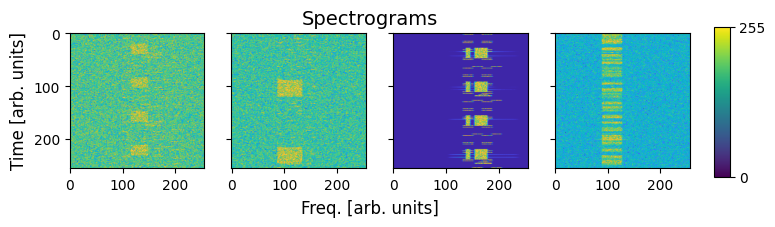

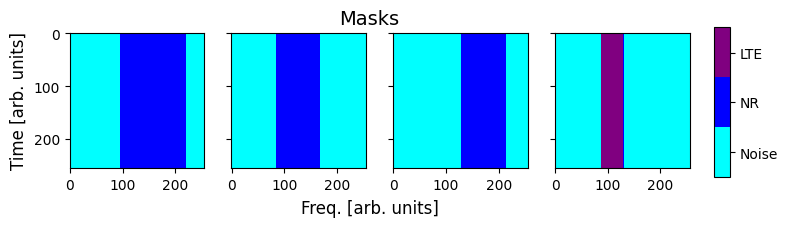

In [13]:
def plot_spects(spects: list[Image.Image]) -> None:
    fig, axes = plt.subplots(figsize=[batch_size * 2, 3], nrows=1, ncols=batch_size, sharey=True)
    fig.text(0.5, 0.75, "Spectrograms", fontsize=title_font_size, ha="center")
    axes[0].set_ylabel("Time [arb. units]", fontsize=label_font_size)
    fig.text(0.5, 0.12, "Freq. [arb. units]", fontsize=label_font_size, ha="center")

    for i, ax in enumerate(axes):
        print(spects[i].size)
        im = ax.imshow(spects[i], vmin=0, vmax=255)

    fig.subplots_adjust(right=0.90)
    cbar_ax = fig.add_axes(rect=[0.93, 0.24, 0.02, 0.5])
    fig.colorbar(im, cax=cbar_ax, ticks=[0, 255])


def plot_masks(masks: list[Image.Image], prediction: bool = False) -> None:
    fig, axes = plt.subplots(figsize=[batch_size * 2, 3], nrows=1, ncols=batch_size, sharey=True)
    if prediction:
        fig.text(0.5, 0.75, "Model Predictions", fontsize=title_font_size, ha="center")
    else:
        fig.text(0.5, 0.75, "Masks", fontsize=title_font_size, ha="center")
    axes[0].set_ylabel("Time [arb. units]", fontsize=label_font_size)
    fig.text(0.5, 0.12, "Freq. [arb. units]", fontsize=label_font_size, ha="center")

    for i, ax in enumerate(axes):
        print(masks[i].size)
        im = ax.imshow(masks[i], vmin=0, vmax=2, cmap=mask_cmap)

    fig.subplots_adjust(right=0.90)
    cbar_ax = fig.add_axes(rect=[0.93, 0.24, 0.02, 0.5])
    cbar = fig.colorbar(im, cax=cbar_ax, ticks=[0.33, 1, 1.66])
    cbar.ax.set_yticklabels(labels)

plot_spects(spects=[inv_transform(i) for i in spects])
plot_masks(masks=[inv_target_transform(i) for i in masks])

In [14]:
import numpy as np

for i in range(len(spects)):
    spect_arr = np.array(inv_transform(spects[i]))
    mask_arr = np.array(inv_target_transform(masks[i]))
    
    for class_idx, name in [(1, "LTE"), (2, "NR")]:
        if np.any(mask_arr == class_idx):
            bg = spect_arr[mask_arr == 0]
            sig = spect_arr[mask_arr == class_idx]
            
            print(f"Sample {i+1} ({name}):")
            print(f"  Signal-to-Background Ratio: {sig.mean() / bg.mean():.2f}x")
            print(f"  95th Percentile (BG vs Sig): {np.percentile(bg, 95):.0f} vs {np.percentile(sig, 95):.0f}\n")

Sample 1 (LTE):
  Signal-to-Background Ratio: 1.01x
  95th Percentile (BG vs Sig): 208 vs 217

Sample 2 (LTE):
  Signal-to-Background Ratio: 1.01x
  95th Percentile (BG vs Sig): 213 vs 222

Sample 3 (LTE):
  Signal-to-Background Ratio: 1.13x
  95th Percentile (BG vs Sig): 168 vs 204

Sample 4 (NR):
  Signal-to-Background Ratio: 1.03x
  95th Percentile (BG vs Sig): 232 vs 225



**Note:** You can view different batches from the dataset by rerunning the previous few code cells.

# Model Training

In this example, we'll use a DeepLabV3 model with a MobileNetV3 (large) backbone. This model is designed to be lightweight and efficient, making it ideal for edge computing devices and quick proof-of-concept demonstrations.

In [15]:
n_classes = 3  # We are dealing with three classes: Noise, NR, and LTE.
model = deeplabv3_mobilenet_v3_large(num_classes=n_classes)

Next, we need a loss function. A loss function, also known as a cost or objective function, measures how well a machine learning 
model's predictions match the actual target values. This quantifies the error between predicted outputs and ground truth labels, providing
feedback that guides the model's training process. For classification problems, we commonly use the [Cross-Entropy Loss](https://machinelearningmastery.com/cross-entropy-for-machine-learning/), especially for 
multi-class classification problems. Let's use the [`CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) class from PyTorch, which allows us to assign different weights to individual classes during the computation of the loss. 

We'll use weights inversely proportional to the relative pixel count for each class. That way, we assign lower weights to overrepresented classes, like noise, and larger weights to underrepresented classes, like NR and LTE. This reduces the impact of noise and allows the model to prioritize learning from NR and LTE signal. Class weighting is not the only way to address data imblance, but it is one of the more straightforward methods.

In [16]:
median_count = statistics.median(list(class_counts.values()))
weight = [median_count / class_counts[k] for k in class_counts.keys()]
loss_function = nn.CrossEntropyLoss(weight=torch.tensor(weight, dtype=torch.float))

print("Class weights: ", {k: round(weight[i], 2) for i, k in enumerate(class_counts.keys())})

Class weights:  {'Noise': 0.27, 'NR': 1.0, 'LTE': 2.04}


In this example, we will train out model using stochastic gradient descent (SGD). SGD is a variant of the standard [gradient descent](https://builtin.com/data-science/gradient-descent) optimizer where the loss function is computed on mini-batches of data rather than the entire dataset. This helps improve computational efficiency and scalability, particularly for large datasets, by updating model parameters based on the gradients computed on our mini-batches.

We'll define the training and validation process of our segmentation model in a [`LightningModule`](https://lightning.ai/docs/pytorch/stable/common/lightning_module.html#lightningmodule). 

In [17]:
class SegmentationSGD(L.LightningModule):

    def __init__(
        self,
        model: nn.Module,
        loss_function: nn.Module,
        n_classes: int,
        learning_rate: float,
        momentum: float,
        weight_decay: float,
        step_size: int,
        gamma: float,
    ):
        """Initializes the SegmentationSGD module."""
        super().__init__()
        self.model = model
        self.loss_function = loss_function
        self.n_classes = n_classes

        self.learning_rate = learning_rate
        self.momentum = momentum
        self.weight_decay = weight_decay

        self.step_size = step_size
        self.gamma = gamma

        self.train_accuracy = MulticlassAccuracy(num_classes=self.n_classes)
        self.val_accuracy = MulticlassAccuracy(num_classes=self.n_classes)

    def forward(self, x: Tensor) -> Tensor:
        """Defines a forward pass through the model."""
        return self.model(x)

    def training_step(self, batch: Tensor, batch_idx: int) -> Tensor:
        """Defines a single training step."""
        image, target = batch
        preds = self(image)["out"]
        loss = self.loss_function(preds, target)
        self.train_accuracy(preds, target)
        self.log(name="train_accuracy", value=self.train_accuracy, prog_bar=True)
        self.log(name="train_loss", value=loss, on_epoch=True, on_step=False, prog_bar=True)
        return loss

    def validation_step(self, batch: Tensor, batch_idx: int) -> Tensor:
        """Defines a single validation step."""
        image, target = batch
        preds = self(image)["out"]
        loss = self.loss_function(preds, target)
        self.val_accuracy(preds, target)
        self.log(name="val_accuracy", value=self.val_accuracy, prog_bar=True)
        self.log(name="val_loss", value=loss, on_epoch=True, on_step=False, prog_bar=True)
        return loss

    def configure_optimizers(self) -> dict[str, Any]:
        """Configure the optimizer and learning rate scheduler."""
        optimizer = torch.optim.SGD(
            self.parameters(), lr=self.learning_rate, momentum=self.momentum, weight_decay=self.weight_decay
        )
        lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=self.step_size, gamma=self.gamma)

        return {"optimizer": optimizer, "lr_scheduler": lr_scheduler}

Our `SegmentationModelSGD` is initialized with several configuration settings that influence the behavior and performance of the machine learning algorithm or model. These parameters are called hyperparameters, and unlike model parameters, which are learned from the data during training, hyperparameters are set prior to training and influence the learning process.

The following hyperparameters are used to configure the optimizer:
- **Momentum:** A parameter that accelerates SGD in the relevant direction and dampens oscillations.
- **Learning Rate:** The rate at which the model parameters are updated during optimization.
- **Weight Decay:** A regularization term added to the loss function to penalize large weights in the model to prevent overfitting.

By gradually reducing the learning rate over epochs, the scheduler can help improve the convergence and stability of the optimization process.
We need to provide the following two parameters, which will be used by the learning rate scheduler to dynamically adjust the learning rate during training:
- **Step Size:** The number of epochs after which the learning rate is reduced.
- **Gamma:** The factor by which the learning rate is reduced after every step-size epochs.

Adjusting these hyperparameters can significantly impact the training process and the final performance of the model, for better or for worse!

In [18]:
segmentation_module = SegmentationSGD(
    model=model,
    loss_function=loss_function,
    n_classes=n_classes,
    learning_rate=0.02,  # Represents the initial learning rate.
    momentum=0.9,
    weight_decay=1.0e-04,
    step_size=10,
    gamma=0.1,
)

Now that we have our model, weighted loss function, and Lightning Module, we are prepared to train our model. If available, we will leverage GPU acceleration. Otherwise, the training process will default to using the CPU. Please be patient; model training time may vary from a few minutes to over an hour depending on the current hardware configuration.

The number of epochs determines how many times the entire dataset will be used to train the model. For this specific model and dataset, 10 epochs should be more than sufficient. However, if you are training on the CPU, you might want to consider reducing the number of training epochs to 4 to save on training time.

In [19]:
n_epochs = 10
# n_epochs = 4  # Suggested for CPU training.

if torch.cuda.is_available():
    print("Training model on GPU.")
    trainer = L.Trainer(accelerator="gpu", max_epochs=n_epochs, logger=True)
    device = "cuda"
else:
    print("Training model on CPU.")
    trainer = L.Trainer(max_epochs=n_epochs, logger=True)
    device = "cpu"

trainer.fit(model=segmentation_module, train_dataloaders=train_loader, val_dataloaders=val_loader)

Training model on GPU.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/mahmoud/Desktop/spectrogram-segmentation/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type               | Params | Mode 
--------------------------------------------------------------
0 | model          | DeepLabV3          | 11.0 M | train
1 | loss_function  | CrossEntropyLoss   | 0      | train
2 | train_accuracy | MulticlassAccuracy | 

Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/home/mahmoud/Desktop/spectrogram-segmentation/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/mahmoud/Desktop/spectrogram-segmentation/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Training: |                                               | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


If you are running this example locally, you can refer to the `metrics.csv` file located in the `lightning_logs` directory for more information regarding training and validation loss and accuracy across training epochs. Please remember to close the `metrics.csv` file before proceeding.

# Model Validation

Having trained our model, the next step is to evaluate its capabilities. To accomplish this, we'll use a suite of standard machine learning metrics. But first, let's take a look at a random batch of predictions.

Because the model returns the probabilities corresponding to the predictions of each class. We need to use `argmax()` to obtain the class with the highest prediction probability. The result is a singe-channel image for each example in the batch, which can be compared directly to the corresponding target mask.

In [20]:
model.eval()
model.to(device)

spects, masks = next(iter(train_loader))
spects = spects.to(device)

with torch.inference_mode():
    preds = (model(spects)["out"]).argmax(1)

print("Predictions:", preds.size())

Predictions: torch.Size([4, 256, 256])


(256, 256)
(256, 256)
(256, 256)
(256, 256)
(256, 256)
(256, 256)
(256, 256)
(256, 256)
<built-in method size of Tensor object at 0x79dc8dc5f340>
<built-in method size of Tensor object at 0x79dc8dc5f390>
<built-in method size of Tensor object at 0x79dc8dc5f390>
<built-in method size of Tensor object at 0x79dc8dc5f390>


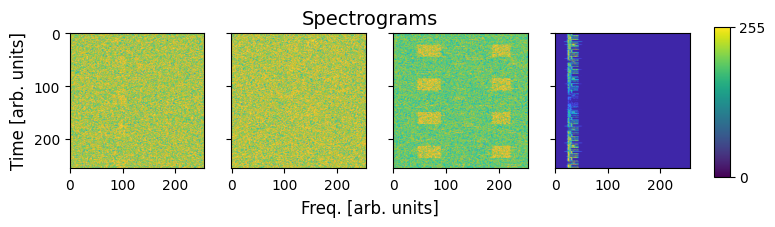

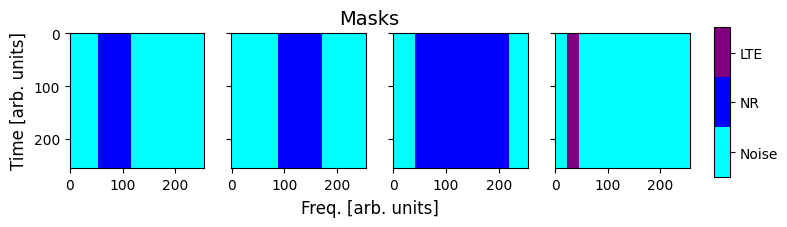

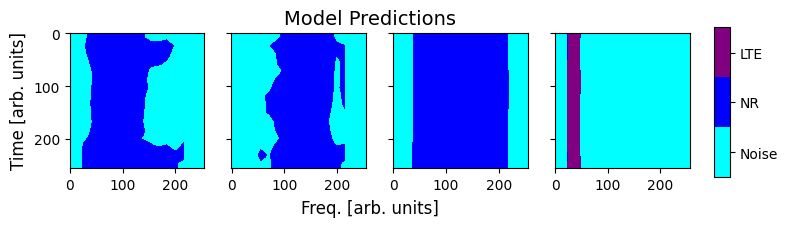

In [21]:
plot_spects(spects=[inv_transform(i.cpu()) for i in spects])
plot_masks(masks=[inv_target_transform(i) for i in masks])
plot_masks(masks=preds.cpu(), prediction=True)

Looks pretty good! To get a more objective sense, let's turn to the metrics. We'll start with model accuracy, calculated as the ratio of correctly predicted pixels to the total number of pixels.

**Note:** You can view different predictions by rerunning the previous few code cells.

In [22]:
scores = trainer.validate(model=segmentation_module, dataloaders=val_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/mahmoud/Desktop/spectrogram-segmentation/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Validation: |                                             | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      val_accuracy           0.965898871421814
        val_loss            0.08365371078252792
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


The accuracy can give us a quick sense of the model's overall performance. However, accuracy alone doesn't tell the whole story. In fact, because of the imbalance in our dataset, a reasonably high accuracy could be achieved by always predicting  noise. The simple accuracy provided above is an unweighted mean of the accuracies over each class.

To gain a better understanding of our model's ability to predict specific classes, let's take a look at the confusion matrix, which provides a more comprehensive overview of model capability. The diagonal elements represent the correct predictions and off-diagonal elements indicate prediction errors.

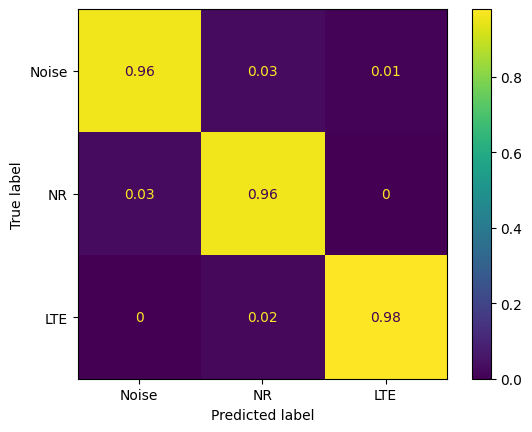

In [23]:
model.to(device)
confusion_matrix = MulticlassConfusionMatrix(num_classes=n_classes, normalize="true").to(device)

with torch.inference_mode():
    for spect, mask in val_loader:
        spect, mask = spect.to(device), mask.to(device)
        pred = (model(spect)["out"]).argmax(dim=1)
        confusion_matrix.update(pred, mask)

confusion_matrix = np.round(confusion_matrix.compute().cpu().numpy(), decimals=2)
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=labels).plot()

Finally, let's generate a more comprehensive report, complete with the following metrics:

- **Recall:** The recall (sensitivity) measures the ability of the model to identify the relevant pixels. A higher recall indicates that the model is better at identifying signal.

- **Precision:** The precision assesses the accuracy of positive predictions. A higher precision indicates that when the model predicts signal, it is more likely to be correct.

- **F1 Score:** The F1 score combines both recall and precision into a single value, providing a more balanced measure of the model's performance. A higher F1 indicates a model with both good precision and recall (fewer false positives and false negatives overall).

- **Intersection over Union (IoU):** The IoU quantifies the overlap between the predicted bounding box or segmented region and the ground truth. A higher IoU value indicates a better alignment between the predicted and actual regions, reflecting a more accurate model.

In [24]:
def print_metrics_report(dataloader: DataLoader) -> None:
    """Compute accuracy, recall, precision, F1 score, and IoU (Intersection over Union),
    and print a report containing these metrics."""
    metrics = [
        MulticlassAccuracy(num_classes=n_classes, average=None),
        MulticlassRecall(num_classes=n_classes, average=None),
        MulticlassPrecision(num_classes=n_classes, average=None),
        MulticlassF1Score(num_classes=n_classes, average=None),
        # The IoU is commonly referred to as Jaccard's Index
        MulticlassJaccardIndex(num_classes=n_classes, average=None),
    ]
    metrics = [m.to(device) for m in metrics]

    with torch.inference_mode():
        for spect, mask in dataloader:
            spect, mask = spect.to(device), mask.to(device)
            pred = (model(spect)["out"]).argmax(dim=1)
            for m in metrics:
                m.update(pred, mask)

    metrics = [m.compute().cpu().numpy() for m in metrics]
    metrics = [np.append(m, statistics.mean(m)) for m in metrics]

    df = pd.DataFrame(
        {
            "Class": np.append(np.asarray(labels), "Mean"),
            "Accuracy": metrics[0],
            "Recall": metrics[1],
            "Precision": metrics[2],
            "F1 Score": metrics[3],
            "IoU": metrics[4],
        }
    )
    print(
        tabulate(
            df, headers="keys", tablefmt="grid", showindex=False, numalign="center", stralign="center", floatfmt=".2f"
        )
    )

In [25]:
print_metrics_report(dataloader=val_loader)

+---------+------------+----------+-------------+------------+-------+
|  Class  |  Accuracy  |  Recall  |  Precision  |  F1 Score  |  IoU  |
+=========+============+==========+=============+============+=======+
|  Noise  |    0.96    |   0.96   |    0.99     |    0.97    | 0.95  |
+---------+------------+----------+-------------+------------+-------+
|   NR    |    0.96    |   0.96   |    0.89     |    0.93    | 0.87  |
+---------+------------+----------+-------------+------------+-------+
|   LTE   |    0.98    |   0.98   |    0.91     |    0.94    | 0.89  |
+---------+------------+----------+-------------+------------+-------+
|  Mean   |    0.97    |   0.97   |    0.93     |    0.95    | 0.90  |
+---------+------------+----------+-------------+------------+-------+


# Challenge Data

In machine learning, out-of-distribution data refers to examples that deviate from those used during training. For example, recall the Spectrogram Sensing dataset comprises 900 combined frames featuring both LTE and NR signals. As we excluded the combined frames from the training process, they represent out-of-distribution data. To get a quick sense of how our model performs on these combined frames, let's take a look at a random batch of predictions.

In [26]:
challenge_dataset = SpectrumSensing(
    source=source, transform=transform, target_transform=target_transform, combined=True
)

challenge_loader = DataLoader(challenge_dataset, batch_size=batch_size, shuffle=True)

In [27]:
spects, masks = next(iter(challenge_loader))
spects = spects.to(device)

with torch.inference_mode():
    preds = (model(spects)["out"]).argmax(1)

print("Predictions:", preds.size())

Predictions: torch.Size([4, 256, 256])


(256, 256)
(256, 256)
(256, 256)
(256, 256)
(256, 256)
(256, 256)
(256, 256)
(256, 256)
<built-in method size of Tensor object at 0x79dc8dd4c320>
<built-in method size of Tensor object at 0x79dc94111900>
<built-in method size of Tensor object at 0x79dc94111900>
<built-in method size of Tensor object at 0x79dc94111900>


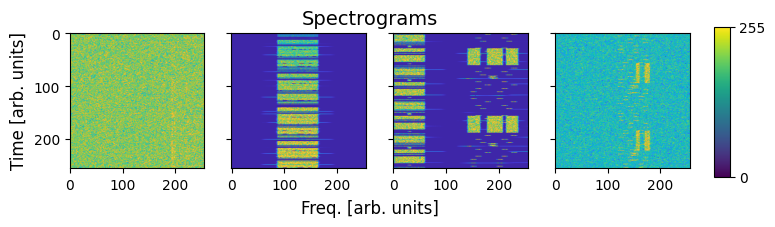

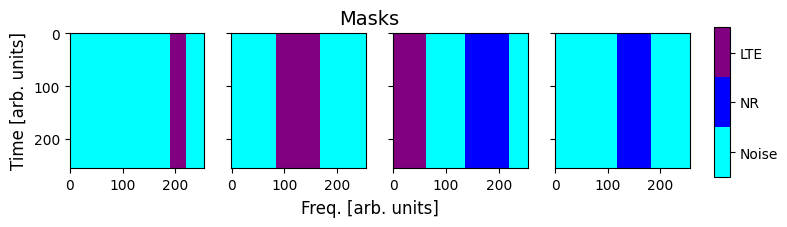

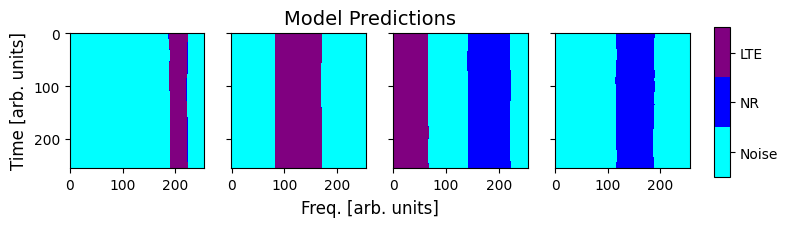

In [28]:
plot_spects(spects=[inv_transform(i.cpu()) for i in spects])
plot_masks(masks=[inv_target_transform(i) for i in masks])
plot_masks(masks=preds.cpu(), prediction=True)

**Note:** You can view different examples by rerunning the previous few code cells.

Now, let's evaluate the same metrics as we did above in the [Model Validation](#Model-Validation) section, but now for the challenge dataset. Given the model's lack of exposure to these combined frames during the training process, we anticipate the model's capabilities to be somewhat diminished. Yet, we still anticipate reasonable results.

In [29]:
print_metrics_report(dataloader=challenge_loader)

+---------+------------+----------+-------------+------------+-------+
|  Class  |  Accuracy  |  Recall  |  Precision  |  F1 Score  |  IoU  |
+=========+============+==========+=============+============+=======+
|  Noise  |    0.94    |   0.94   |    0.95     |    0.95    | 0.90  |
+---------+------------+----------+-------------+------------+-------+
|   NR    |    0.91    |   0.91   |    0.88     |    0.89    | 0.81  |
+---------+------------+----------+-------------+------------+-------+
|   LTE   |    0.88    |   0.88   |    0.90     |    0.89    | 0.81  |
+---------+------------+----------+-------------+------------+-------+
|  Mean   |    0.91    |   0.91   |    0.91     |    0.91    | 0.84  |
+---------+------------+----------+-------------+------------+-------+


# Conclusions & Next Steps

In this example, we used PyTorch and Lightning to train a DeepLabV3 model to identify and differentiate between 5G NR and 4G LTE signals within wideband spectrograms, showcasing one of the ways we leverage machine learning to identify things in the wireless spectrum. This involved data analysis and preprocessing, choosing a loss function and optimizer, model training, model performance validation, and finally testing the model on out-of-distribution frames containing both NR and LTE signal.

The capability to differentiate and recognize various signals finds direct applications in spectrum sensing, which is fundamental to autonomous spectrum management, and brings us one step closer to more holistic intelligent radio solutions! 📡🚀

We hope this example was informative. Here are some next steps you can take to further explore and expand upon what you've learned:

- **Experiment with the Hyperparameters:** Adjust the values of hyperparameters such as the number of training epochs, batch size, and learning rate, and observe how these configurations influence model training and performance. After gaining insights through manual hyperparameter tuning, explore automated approaches using tools like [Ray Tune](https://pytorch.org/tutorials/beginner/hyperparameter_tuning_tutorial.html) or [Optuna](https://optuna.org/).

- **Experiment with DeepLabV3's ResNet Models:** DeepLabV3 also provides models with ResNet-50 and ResNet-101 backbones. These ResNet models are deeper and more complex, and generally offer better model performance than MobileNetV3, which is designed to be lightweight and efficient. Because all DeepLabV3 models implement the same interface, no code changes are required. However, some hyperparameter tuning and/or a larger dataset may be required to train these models effectively. These models have already been imported into this notebook for your convenience.

- **Explore Alternative Solutions to Class Imbalance:** In this example, we addressed class imbalance in our dataset using a weighted cross-entropy loss function. Research and implement alternative strategies or loss functions designed to address imbalance in image datasets.

- **Integrate Combined Frames:** In this example, we trained exclusively on the individual NR and LTE frames. Try integrating the combined frames that contain both the NR and LTE signals into the training process, and evaluate the effect on model performance.

- **Test your Model on Captured Radio Data:** If you have radio hardware available, consider testing your model on real recordings of live radio data. Check out this article from MathWorks for more information on how to capture NR and LTE signals: [Capture and Label NR and LTE Signals for AI Training](https://www.mathworks.com/help/wireless-testbench/ug/capture-and-label-nr-and-lte-signals-for-ai-training.html).

- **Explore RIA Core on GitHub (Coming soon!):** At Qoherent, we're building [Radio Intelligence Applications](https://qoherent.ai/radiointelligenceapps-project/) (RIA) to drive the creation of intelligent radios. Check out [RIA Core](https://github.com/qoherent/ria)—the free and open-source foundation of RIA—and consider contributing to the project. ⭐